# Project 10 -- Tanay Patel

**TA Help:** (for instance) John Smith, Alice Jones, etc., list names of any TAs who helped you

- For example: Help with figuring out how to write a function (describe the tasks that they helped you with)

**Collaboration:** My Friend in CS, My Uncle, Another Student, etc., list names of any other people who helped you

(describe the tasks that they helped you with)
- For example: helped figuring out how to load the dataset.
- Another example: helped debug error with my plot.

**Internet Resources:** Stack Exchange, Stack Overflow, etc.

(describe any information that you learned from internet resources, including the URLs)
- data frames in Pandas versus R from StackOverflow  https://stackoverflow.com/questions/8991709/why-were-pandas-merges-in-python-faster-than-data-table-merges-in-r-in-2012

**ChatGPT, Gemini, Claude, etc:** Any language models or generative AI chatbots that helped you.

(if you used any such tools, please tell us here)
- For example:  I asked ChatGPT how to define a new data frames
- Another example:  Gemini told me how to make a function for sorting my data

- ***Link to AI Chat History***: Please share a link to your chat if you used AI (ex. ChatGPT Shared Links)
**OVERALL MESSAGE:** Any time that you used anything except your brain to solve the questions in these projects, you need to disclose such resources at the start of the project, with details about your usage of the tools.

**YOUR OWN WORK:** Even when you utilize other resources, do NOT just copy and paste.  Write all explanations in your own words, using several sentences in English, which are understandable and which you wrote (and did not just copy and paste).

## Question 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

myDF = pd.read_csv("/anvil/projects/tdm/data/death_records/DeathRecords.csv")
race_df = pd.read_csv("/anvil/projects/tdm/data/death_records/Race.csv")
marital_df = pd.read_csv("/anvil/projects/tdm/data/death_records/MaritalStatus.csv")

In [2]:
race_counts = myDF["Race"].value_counts()

<Axes: xlabel='Race'>

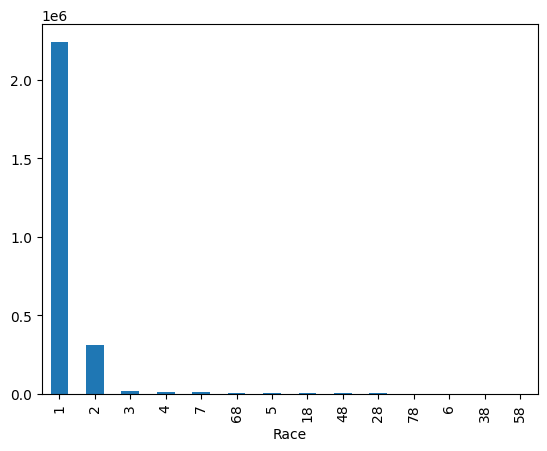

In [3]:
race_counts.plot(kind="bar")

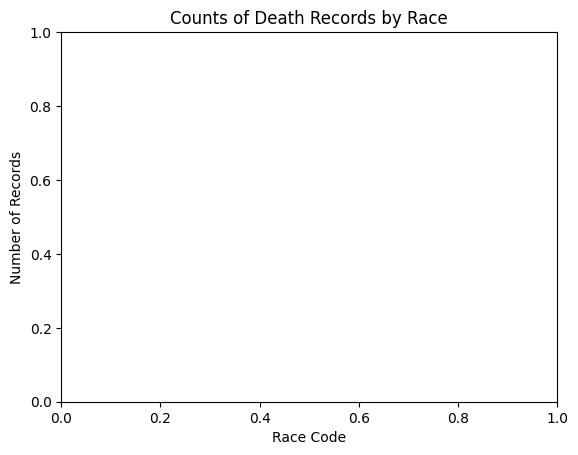

In [4]:
plt.title("Counts of Death Records by Race")
plt.xlabel("Race Code")
plt.ylabel("Number of Records")
plt.show()

## 1.1

In the Race column, I saw that the values are stored as numbers instead of actual race names. By using the Race.csv decoder file, I was able to understand what each number represents, which made the data much easier to interpret.

## 1.2

Some other columns that seem like they need a decoder are MaritalStatus, Education, and PlaceOfDeath, since they also use coded values instead of clear labels. These columns could be interesting to work with once I understand what their values actually mean.

## 1.3
58 had the smallest number of entries.

In question 1, we read in the Death Records dataset along with the Race and MaritalStatus decoder datasets to better understand what the coded values represent. Then we examined the value counts of the Race column and used the decoder file to interpret what each numeric value means. After that, we created a plot to visualize how the counts of each race were distributed.

## Question 2

In [17]:
filtered = myDF[myDF["Race"] != 1]

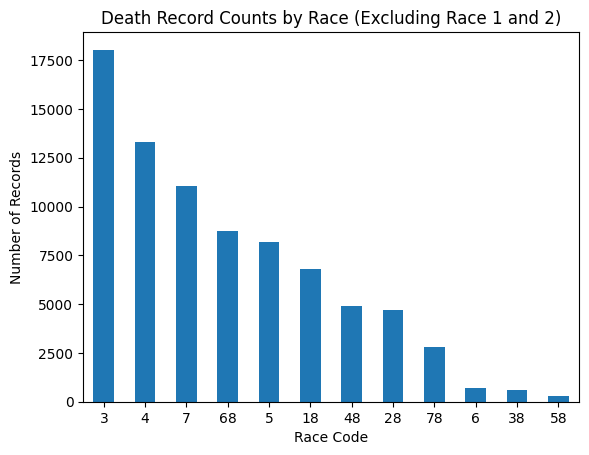

In [16]:
filtered = filtered[filtered["Race"] != 2]

filtered_counts = filtered["Race"].value_counts()

filtered_counts.plot(kind="bar")

plt.title("Death Record Counts by Race (Excluding Race 1 and 2)")
plt.xlabel("Race Code")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

## 2.1

I customized the plot by removing extremely large categories to make the smaller categories more visible and used a bar plot for clearer comparison between categories. I also added a title and axis labels to make the plot more understandable.

## 2.2

I ensured readability by clearly labeling the axes and including in the title which race categories were excluded. This helps others understand exactly what data is being shown without confusion.

## 2.3

I excluded Race 1 (and optionally Race 2) because their counts were significantly higher than the others, which made it difficult to compare smaller categories on the same scale. Removing them allowed for a clearer and more meaningful comparison of the remaining race groups.

In question 2, we filtered out the most dominant race category to make the data more readable and created a new plot focusing on the remaining categories. Then we experimented with removing additional large categories to improve the clarity of the visualization. After that, we customized the plot with labels and titles to clearly explain what data was included and excluded.

## Question 3

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

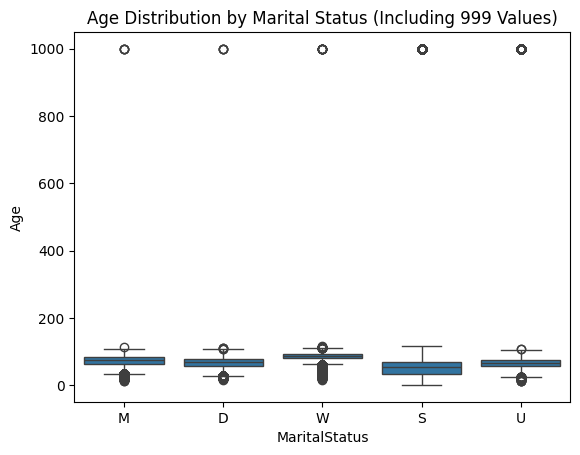

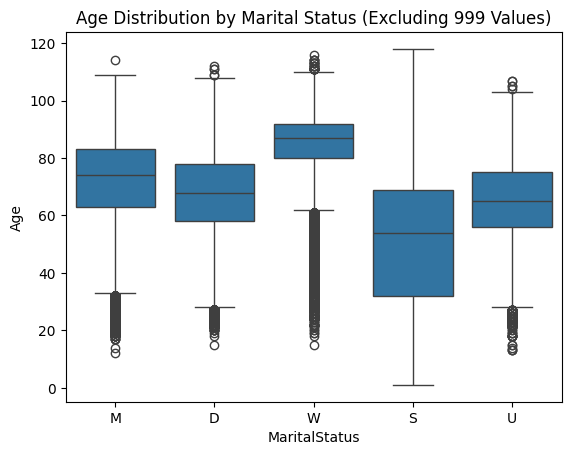

In [20]:
sns.boxplot(x="MaritalStatus", y="Age", data=myDF)
plt.title("Age Distribution by Marital Status (Including 999 Values)")
plt.show()

cleanDF = myDF[myDF["Age"] != 999]

sns.boxplot(x="MaritalStatus", y="Age", data=cleanDF)
plt.title("Age Distribution by Marital Status (Excluding 999 Values)")
plt.show()

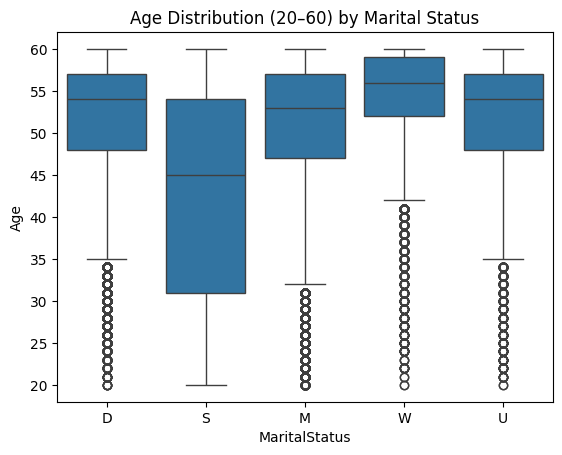

In [21]:
rangeDF = cleanDF[(cleanDF["Age"] >= 20) & (cleanDF["Age"] <= 60)]

sns.boxplot(x="MaritalStatus", y="Age", data=rangeDF)
plt.title("Age Distribution (20–60) by Marital Status")
plt.show()

## 3.2

The boxplot including the 999 values is not very useful because the extreme outliers stretch the scale and compress the rest of the data. After removing the 999 values, the boxplot becomes much clearer and allows us to better compare the age distributions across different marital statuses.

## 3.3 

The boxplot for the specific age range shows a more focused view of how marital status varies within a realistic age group, making patterns easier to see. Compared to the full dataset, it removes noise from very young or very old ages and highlights differences in typical adult age ranges across marital statuses.

In question 3, we imported the seaborn library and created a boxplot comparing the Age column with the MaritalStatus column. Then we removed the invalid age value of 999 and created a cleaner boxplot to better understand the data distribution. After that, we focused on a specific age range and created another boxplot to analyze how marital status relates within that range.

## Question 4

/tmp/ipykernel_620/1791425954.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="MaritalStatus", y="Age", data=subset, palette=["skyblue", "salmon"])


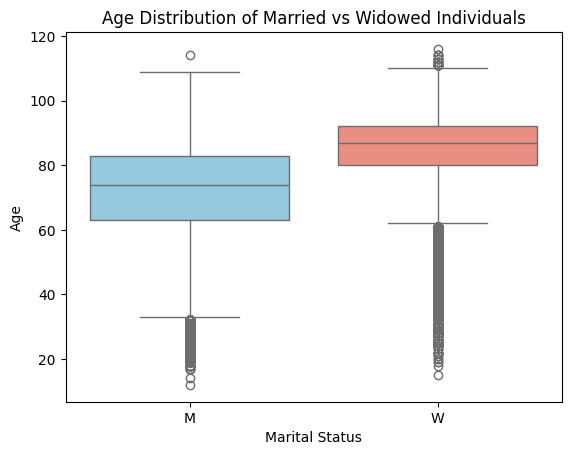

In [25]:
subset = cleanDF[cleanDF["MaritalStatus"].isin(["M", "W"])]

sns.boxplot(x="MaritalStatus", y="Age", data=subset, palette=["skyblue", "salmon"])
plt.title("Age Distribution of Married vs Widowed Individuals")
plt.xlabel("Marital Status")
plt.ylabel("Age")
plt.show()

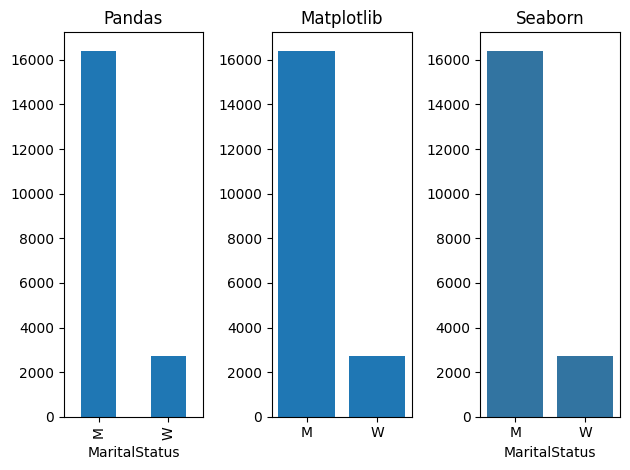

In [26]:
subset2 = subset[subset["Age"] == 60]

my_counts = subset2["MaritalStatus"].value_counts()

fig, axes = plt.subplots(nrows=1, ncols=3)
labels = my_counts.index
counts = my_counts.values

my_counts.plot(kind="bar", ax=axes[0], title="Pandas")

axes[1].bar(labels, counts)
axes[1].set_title("Matplotlib")

sns.barplot(x=labels, y=counts, ax=axes[2])
axes[2].set_title("Seaborn")

plt.tight_layout()
plt.show()

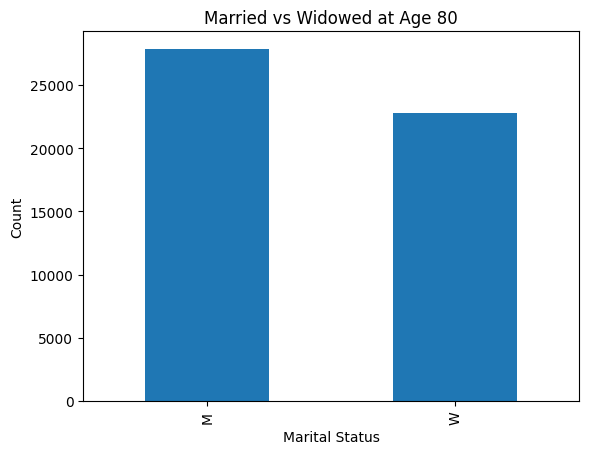

In [27]:
subset3 = subset[subset["Age"] == 80]
my_counts2 = subset3["MaritalStatus"].value_counts()

my_counts2.plot(kind="bar", title="Married vs Widowed at Age 80")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.show()

## 4.1

The boxplot shows that widowed individuals tend to have higher ages compared to married individuals, which makes sense since people are more likely to become widowed later in life. The spread of ages for married individuals is wider, while widowed individuals are more concentrated in older age ranges.

## 4.2

The barplot for age 60 shows how many people were married versus widowed at that specific age, and typically more people are married than widowed at this age. When comparing this to an older age like 80, the number of widowed individuals increases significantly, showing how marital status shifts with age.

## 4.3

Pandas is the simplest to use and requires the least code, but has limited customization. Matplotlib provides more control over the plot but requires more setup, while seaborn offers a balance by providing better-looking plots with relatively simple code.

In question 4, we created a subset of the data that included only married and widowed individuals and made a boxplot comparing their age distributions. Then we filtered the data further to focus on people of a specific age and created barplots to compare the counts of married versus widowed individuals. After that, we repeated this for another age and compared how the distributions change.

## Question 5

In [29]:
my_first_counts  = cleanDF[cleanDF["Age"] == 60]["MaritalStatus"].value_counts().sort_index()
my_second_counts = cleanDF[cleanDF["Age"] == 70]["MaritalStatus"].value_counts().sort_index()
my_third_counts  = cleanDF[cleanDF["Age"] == 80]["MaritalStatus"].value_counts().sort_index()

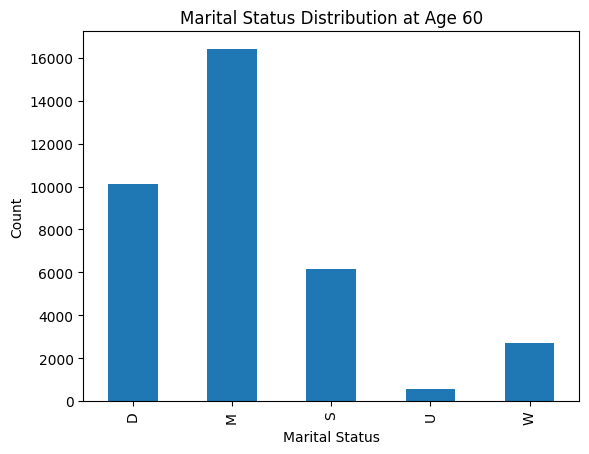

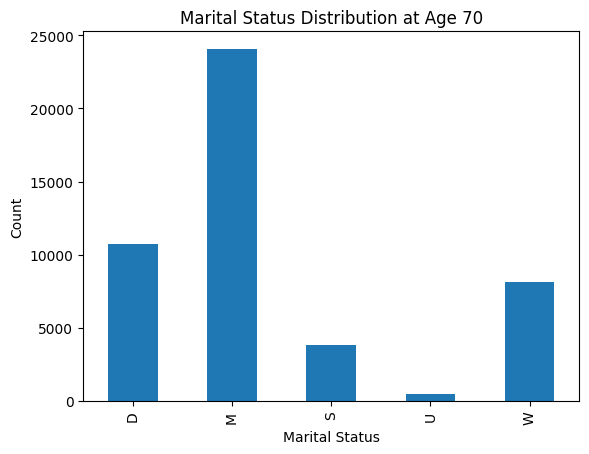

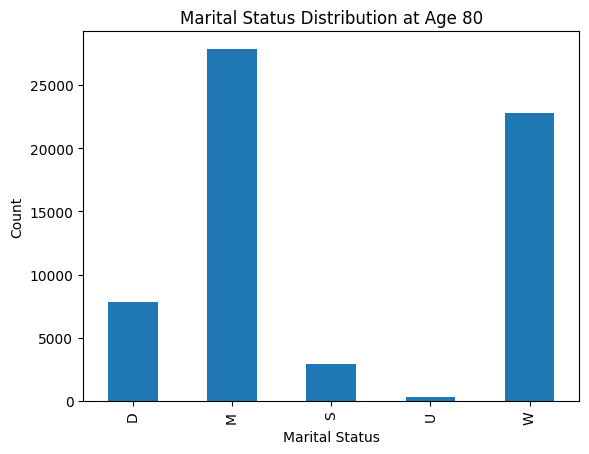

In [30]:
my_first_counts.plot(kind="bar")
plt.title("Marital Status Distribution at Age 60")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.show()

my_second_counts.plot(kind="bar")
plt.title("Marital Status Distribution at Age 70")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.show()

my_third_counts.plot(kind="bar")
plt.title("Marital Status Distribution at Age 80")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.show()

## 5.2

As age increases, the number of widowed individuals increases while the number of married individuals tends to decrease. This shows a clear shift in marital status distribution as people grow older, with widowed becoming more common in higher age groups.

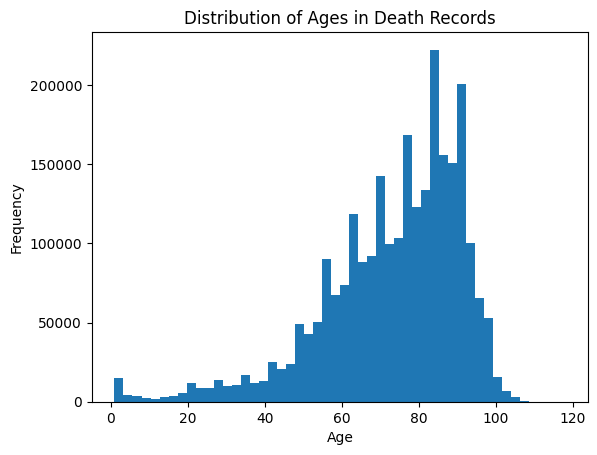

In [31]:
cleanDF["Age"].plot(kind="hist", bins=50)

plt.title("Distribution of Ages in Death Records")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## 5.3

This histogram shows how ages are distributed across all death records, highlighting which age groups have the highest number of records. It helps identify patterns such as higher frequencies in older age ranges.

In question 5, we created subsets of the data for people aged 60, 70, and 80 and calculated the value counts of marital statuses for each group. Then we plotted these counts as separate barplots to compare how marital status changes across these ages. After that, we created an additional plot using the dataset to explore another pattern and explained what insights could be observed from it.

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
